# **Trajectory Stitching with Human Reference Models**

---

**Overview:**

1. Implement **classifier-guided diffusion** for trajectory generation
2. Understand **negative behavior guidance** for distribution shift correction
3. Implement **trajectory stitching** with conditional diffusion
4. Integrate **Human Reference Models (HRM)** as planning priors

<br/>


## Setup & Imports

In [14]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from collections import deque
import heapq
from typing import List, Tuple, Optional, Dict
from dataclasses import dataclass
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## Part A: Environment & HRM Setup 

We use a 2D navigation environment with obstacles. The **Human Reference Model (HRM)** provides planning priors through:
1. A* pathfinding for subgoal generation
2. Heatmap representation of preferred trajectories
3. Direction field for goal-directed navigation

In [2]:
@dataclass
class MazeConfig:
    """Configuration for the maze environment."""
    size: int = 10
    start: Tuple[float, float] = (1.0, 1.0)
    goal: Tuple[float, float] = (8.5, 8.5)
    obstacles: List[Tuple[int, int]] = None

    def __post_init__(self):
        if self.obstacles is None:
            self.obstacles = [
                (4, 4), (5, 4), (4, 5), (5, 5),  # Center block
                (7, 2), (8, 2),                   # Lower-right
                (2, 7), (2, 8),                   # Upper-left
            ]

class MazeEnvironment:
    """2D Navigation Environment with continuous state/action space."""

    def __init__(self, config: MazeConfig):
        self.config = config
        self.size = config.size
        self.start = np.array(config.start)
        self.goal = np.array(config.goal)
        self.obstacles = set(config.obstacles)
        self.state = self.start.copy()

    def reset(self) -> np.ndarray:
        """Reset to start position."""
        self.state = self.start.copy()
        return self.state.copy()

    def is_valid_position(self, pos: np.ndarray) -> bool:
        """Check if position is valid (in bounds and not in obstacle)."""
        if pos[0] < 0.5 or pos[0] > self.size - 0.5:
            return False
        if pos[1] < 0.5 or pos[1] > self.size - 0.5:
            return False
        cell = (int(pos[0]), int(pos[1]))
        return cell not in self.obstacles

    def step(self, action: np.ndarray) -> Tuple[np.ndarray, float, bool]:
        """
        Take action in environment.
        Action: [dx, dy] velocity vector, clipped to max magnitude 0.5
        Returns: (next_state, reward, done)
        """
        action = np.clip(action, -0.5, 0.5)

        next_state = self.state + action

        if self.is_valid_position(next_state):
            self.state = next_state
            wall_penalty = 0.0
        else:
            wall_penalty = -0.5

        dist_to_goal = np.linalg.norm(self.state - self.goal)
        reward = -0.01 * dist_to_goal + wall_penalty

        done = dist_to_goal < 0.8
        if done:
            reward += 10.0

        return self.state.copy(), reward, done

    def render(self, ax=None, trajectories=None, title="Maze Environment"):
        """Visualize the environment."""
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 8))

        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

        for (ox, oy) in self.obstacles:
            rect = Rectangle((ox, oy), 1, 1, facecolor='gray', edgecolor='black')
            ax.add_patch(rect)

        ax.plot(*self.start, 'go', markersize=15, label='Start', zorder=5)
        ax.plot(*self.goal, 'y*', markersize=20, label='Goal', zorder=5)

        # Draw trajectories if provided
        if trajectories is not None:
            for traj in trajectories:
                traj = np.array(traj)
                ax.plot(traj[:, 0], traj[:, 1], 'b-', alpha=0.5, linewidth=1)

        ax.legend(loc='upper left')
        ax.set_title(title)
        return ax

In [3]:
class HumanReferenceModel:
    """
    Human Reference Model (HRM) for planning priors.

    Provides:
    1. A* pathfinding for subgoal generation
    2. Heatmap of preferred trajectory regions
    3. Direction field for navigation guidance
    4. Scoring function for trajectory quality
    """

    def __init__(self, env: MazeEnvironment, resolution: int = 50):
        self.env = env
        self.resolution = resolution
        self.subgoals = self._compute_subgoals()
        self.heatmap = self._generate_heatmap()
        self.direction_field = self._compute_direction_field()

    def _compute_subgoals(self) -> List[np.ndarray]:
        """Use A* to find path from start to goal."""
        start_cell = (int(self.env.start[0]), int(self.env.start[1]))
        goal_cell = (int(self.env.goal[0]), int(self.env.goal[1]))

        def heuristic(a, b):
            return np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

        def get_neighbors(cell):
            x, y = cell
            neighbors = []
            for dx, dy in [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < self.env.size and 0 <= ny < self.env.size:
                    if (nx, ny) not in self.env.obstacles:
                        neighbors.append((nx, ny))
            return neighbors

        frontier = [(0, start_cell)]
        came_from = {start_cell: None}
        cost_so_far = {start_cell: 0}

        while frontier:
            _, current = heapq.heappop(frontier)

            if current == goal_cell:
                break

            for neighbor in get_neighbors(current):
                new_cost = cost_so_far[current] + heuristic(current, neighbor)
                if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                    cost_so_far[neighbor] = new_cost
                    priority = new_cost + heuristic(neighbor, goal_cell)
                    heapq.heappush(frontier, (priority, neighbor))
                    came_from[neighbor] = current

        path = []
        current = goal_cell
        while current is not None:
            path.append(np.array([current[0] + 0.5, current[1] + 0.5]))
            current = came_from.get(current)
        path.reverse()

        return path

    def _generate_heatmap(self) -> np.ndarray:
        """Generate heatmap showing preferred trajectory regions."""
        heatmap = np.zeros((self.resolution, self.resolution))

        for i in range(len(self.subgoals) - 1):
            p1 = self.subgoals[i]
            p2 = self.subgoals[i + 1]

            for t in np.linspace(0, 1, 30):
                p = p1 + t * (p2 - p1)
                hx = int(p[0] / self.env.size * self.resolution)
                hy = int(p[1] / self.env.size * self.resolution)
                hx = np.clip(hx, 0, self.resolution - 1)
                hy = np.clip(hy, 0, self.resolution - 1)
                heatmap[hy, hx] = 1.0

        heatmap = gaussian_filter(heatmap, sigma=4)

        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        return heatmap

    def _compute_direction_field(self) -> np.ndarray:
        """Compute direction field pointing toward nearest subgoal."""
        field = np.zeros((self.resolution, self.resolution, 2))

        for i in range(self.resolution):
            for j in range(self.resolution):
                x = (i + 0.5) / self.resolution * self.env.size
                y = (j + 0.5) / self.resolution * self.env.size
                pos = np.array([x, y])

                min_dist = float('inf')
                closest_sg_idx = -1
                target = self.env.goal

                for sg_idx, sg_item in enumerate(self.subgoals):
                    dist = np.linalg.norm(pos - sg_item)
                    if dist < min_dist:
                        min_dist = dist
                        closest_sg_idx = sg_idx

                if closest_sg_idx != -1 and closest_sg_idx < len(self.subgoals) - 1:
                    target = self.subgoals[closest_sg_idx + 1]

                direction = target - pos
                norm = np.linalg.norm(direction)
                if norm > 1e-6:
                    direction = direction / norm

                field[j, i] = direction

        return field

    def get_heatmap_value(self, pos: np.ndarray) -> float:
        """Get heatmap value at continuous position."""
        hx = int(pos[0] / self.env.size * self.resolution)
        hy = int(pos[1] / self.env.size * self.resolution)
        hx = np.clip(hx, 0, self.resolution - 1)
        hy = np.clip(hy, 0, self.resolution - 1)
        return self.heatmap[hy, hx]

    def get_direction(self, pos: np.ndarray) -> np.ndarray:
        """Get recommended direction at position."""
        hx = int(pos[0] / self.env.size * self.resolution)
        hy = int(pos[1] / self.env.size * self.resolution)
        hx = np.clip(hx, 0, self.resolution - 1)
        hy = np.clip(hy, 0, self.resolution - 1)
        return self.direction_field[hy, hx]

    def get_direction_to_goal(self, pos: np.ndarray) -> np.ndarray:
        """Get unit direction vector toward goal."""
        direction = self.env.goal - pos
        norm = np.linalg.norm(direction)
        if norm > 1e-6:
            return direction / norm
        return np.zeros(2)

    def score_trajectory(self, states: np.ndarray) -> float:
        """
        Score a trajectory based on HRM criteria.
        Higher score = better trajectory.
        """
        score = 0.0

        for i, s in enumerate(states):
            score += self.get_heatmap_value(s) * 2.0

            dist_to_goal = np.linalg.norm(s - self.env.goal)
            score -= dist_to_goal * 0.1

            if i > 0:
                move_dir = states[i] - states[i-1]
                move_norm = np.linalg.norm(move_dir)
                if move_norm > 1e-6:
                    move_dir = move_dir / move_norm
                    ideal_dir = self.get_direction(states[i-1])
                    alignment = np.dot(move_dir, ideal_dir)
                    score += alignment * 1.0

        final_dist = np.linalg.norm(states[-1] - self.env.goal)
        if final_dist < 0.8:
            score += 20.0

        return score

    def visualize(self):
        """Visualize HRM components."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        ax = axes[0]
        im = ax.imshow(self.heatmap, origin='lower', extent=[0, self.env.size, 0, self.env.size],
                      cmap='YlOrRd', alpha=0.7)
        plt.colorbar(im, ax=ax, label='Preference')

        for (ox, oy) in self.env.obstacles:
            rect = Rectangle((ox, oy), 1, 1, facecolor='gray', edgecolor='black', alpha=0.8)
            ax.add_patch(rect)

        ax.plot(*self.env.start, 'go', markersize=12, label='Start')
        ax.plot(*self.env.goal, 'y*', markersize=15, label='Goal')
        ax.set_title('HRM Heatmap')
        ax.legend()

        ax = axes[1]
        self.env.render(ax=ax, title='A* Path (Subgoals)')
        subgoals = np.array(self.subgoals)
        ax.plot(subgoals[:, 0], subgoals[:, 1], 'r-o', linewidth=2, markersize=8, label='A* Path')
        ax.legend()

        plt.tight_layout()
        plt.show()

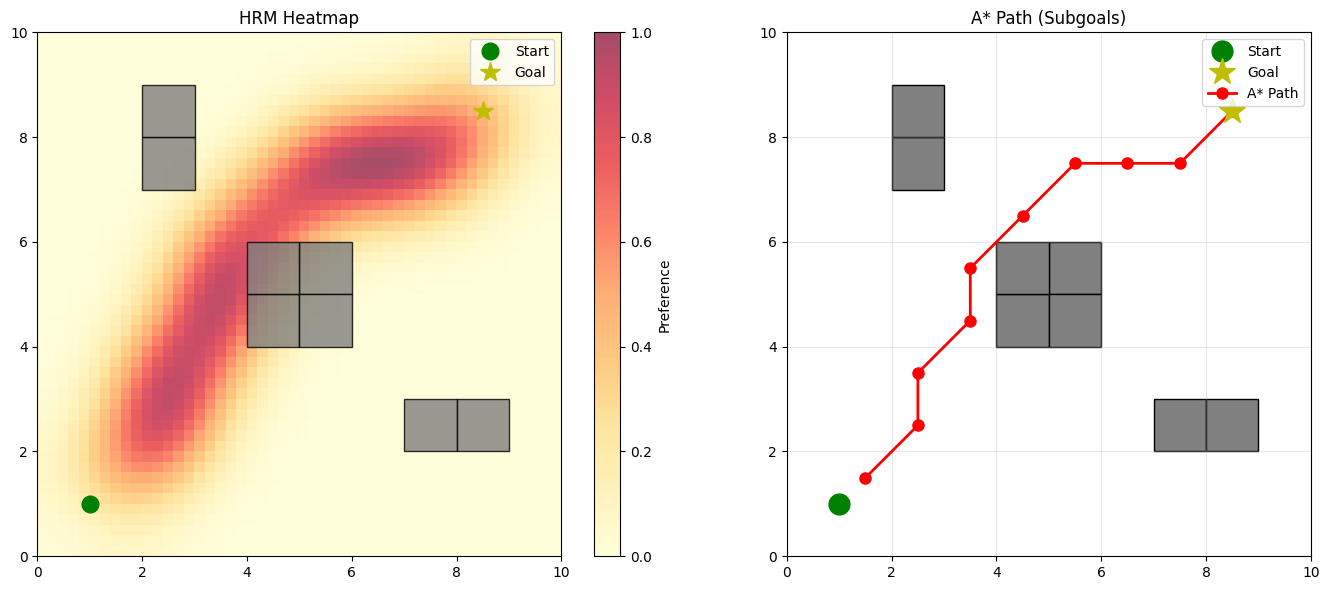

In [4]:
# Initialize environment and HRM
config = MazeConfig()
env = MazeEnvironment(config)
hrm = HumanReferenceModel(env)

hrm.visualize()

---
## Part B: Behavior Policy & Data Collection

We define a **behavior policy β(a|s)** that explores the environment. This policy should:
- Be suboptimal (to create distribution shift)
- But still reach the goal sometimes (30-50% success) so diffusion learns useful patterns

In [ ]:
class GaussianPolicy(nn.Module):
    """
    Gaussian Policy: π(a|s) = N(μ(s), σ²)
    """

    def __init__(self, state_dim: int = 2, action_dim: int = 2, hidden_dim: int = 64,
                 log_std_init: float = -1.0):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, action_dim)
        )

        self.log_std = nn.Parameter(torch.ones(action_dim) * log_std_init)

    def forward(self, state: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        mean = self.network(state)
        std = torch.exp(self.log_std).expand_as(mean)
        return mean, std

    def sample(self, state: torch.Tensor) -> torch.Tensor:
        mean, std = self.forward(state)
        noise = torch.randn_like(mean)
        action = mean + std * noise
        return torch.clamp(action, -0.5, 0.5)

    def log_prob(self, state: torch.Tensor, action: torch.Tensor) -> torch.Tensor:
        """
        Compute log π(a|s) for Gaussian policy.

        Formula: log N(a; μ, σ²) = -0.5 * [(a-μ)²/σ² + log(2πσ²)]
        Sum over action dimensions.

        Returns: (batch,) tensor
        """
        mean, std = self.forward(state)
        var = std ** 2

        # Compute element-wise log probability
        log_prob_element = -0.5 * ((action - mean)**2 / var + torch.log(2 * np.pi * var))

        # Sum over action dimensions (dim=-1) to get joint probability
        return log_prob_element.sum(dim=-1)

    def score(self, state: torch.Tensor, action: torch.Tensor) -> torch.Tensor:
        """
        Compute ∇_a log π(a|s) - the score function.

        For Gaussian: ∇_a log N(a; μ, σ²) = -(a - μ) / σ²

        Returns: (batch, action_dim) tensor
        """
        mean, std = self.forward(state)
        var = std ** 2

        # Compute the score (gradient w.r.t action)
        return -(action - mean) / var

In [6]:
class BehaviorPolicy:
    """
    Behavior policy for data collection.
    Uses noisy goal-directed strategy that reaches goal ~40% of time.
    """

    def __init__(self, env: MazeEnvironment, hrm: HumanReferenceModel):
        self.env = env
        self.hrm = hrm
        self.policy = GaussianPolicy(state_dim=2, action_dim=2, log_std_init=-0.5)
        self._pretrain_policy()

    def _pretrain_policy(self, n_steps: int = 3000):
        """Pre-train behavior policy to be suboptimal but functional."""
        optimizer = torch.optim.Adam(self.policy.parameters(), lr=1e-3)

        for step in range(n_steps):
            states_np = np.random.rand(64, 2) * (self.env.size - 1) + 0.5
            states = torch.tensor(states_np, dtype=torch.float32)

            target_actions = []
            for s in states_np:
                goal_dir = self.hrm.get_direction_to_goal(s)
                hrm_dir = self.hrm.get_direction(s)

                direction = 0.6 * goal_dir + 0.4 * hrm_dir
                direction = direction / (np.linalg.norm(direction) + 1e-6)

                speed = 0.25 + np.random.randn() * 0.05
                action = direction * speed

                # Add noise to make suboptimal
                action += np.random.randn(2) * 0.08
                target_actions.append(action)

            target = torch.tensor(np.array(target_actions), dtype=torch.float32)

            mean, _ = self.policy(states)
            loss = ((mean - target) ** 2).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    def get_action(self, state: np.ndarray) -> np.ndarray:
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            action = self.policy.sample(state_t)
            return action.squeeze(0).numpy()

    def log_prob(self, state: torch.Tensor, action: torch.Tensor) -> torch.Tensor:
        return self.policy.log_prob(state, action)

    def score(self, state: torch.Tensor, action: torch.Tensor) -> torch.Tensor:
        return self.policy.score(state, action)

In [7]:
def collect_behavior_data(env: MazeEnvironment, behavior_policy: BehaviorPolicy,
                          n_trajectories: int = 200, max_steps: int = 80) -> List[Dict]:
    """Collect trajectories from behavior policy."""
    trajectories = []

    for _ in range(n_trajectories):
        state = env.reset()
        states = [state.copy()]
        actions = []
        rewards = []

        for _ in range(max_steps):
            action = behavior_policy.get_action(state)
            next_state, reward, done = env.step(action)

            actions.append(action.copy())
            rewards.append(reward)
            states.append(next_state.copy())
            state = next_state

            if done:
                break

        trajectories.append({
            'states': np.array(states),
            'actions': np.array(actions),
            'rewards': np.array(rewards)
        })

    return trajectories

In [8]:
# Initialize behavior policy and collect data
print("Training behavior policy...")
behavior_policy = BehaviorPolicy(env, hrm)

print("Collecting behavior data...")
behavior_data = collect_behavior_data(env, behavior_policy, n_trajectories=300, max_steps=80)

# Check success rate
success_count = sum(1 for t in behavior_data if np.linalg.norm(t['states'][-1] - env.goal) < 0.8)
print(f"\nCollected {len(behavior_data)} trajectories")
print(f"Average trajectory length: {np.mean([len(t['rewards']) for t in behavior_data]):.1f}")
print(f"Success rate: {success_count / len(behavior_data) * 100:.1f}%")

Training behavior policy...

Collected 300 trajectories
Average trajectory length: 74.1
Success rate: 37.3%


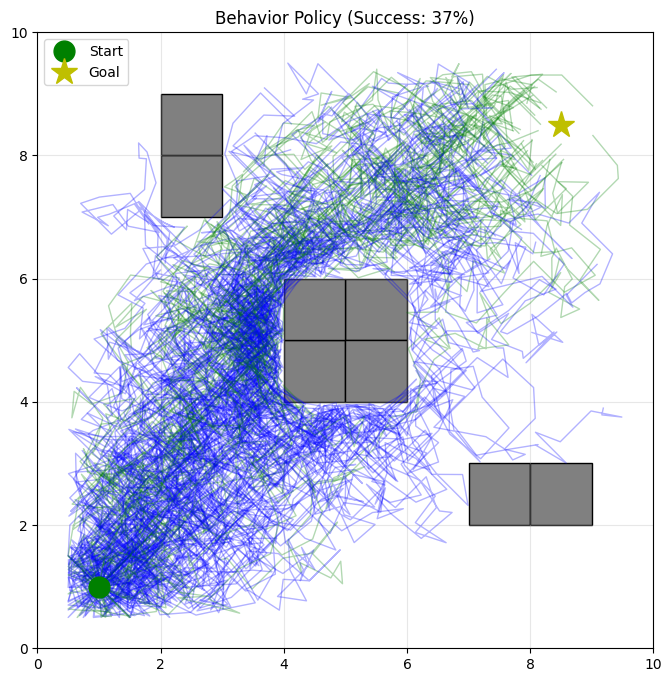

In [9]:
# Visualize behavior trajectories
fig, ax = plt.subplots(figsize=(8, 8))

# Color by success
for t in behavior_data[:100]:
    states = t['states']
    success = np.linalg.norm(states[-1] - env.goal) < 0.8
    color = 'green' if success else 'blue'
    ax.plot(states[:, 0], states[:, 1], '-', color=color, alpha=0.3, linewidth=1)

env.render(ax=ax, title=f'Behavior Policy (Success: {success_count/len(behavior_data)*100:.0f}%)')
plt.show()

---
## Part C: Conditional Diffusion Model

We train a conditional diffusion model on sub-trajectories of length `w`.

In [ ]:
class SubTrajectoryDataset(Dataset):
    """Dataset of sub-trajectories for training conditional diffusion."""

    def __init__(self, trajectories: List[Dict], window_size: int = 8):
        self.window_size = window_size
        self.windows = []
        self.conditions = []

        for traj in trajectories:
            states = traj['states']
            actions = traj['actions']

            for i in range(len(actions) - window_size + 1):
                window_states = states[i:i+window_size+1]
                window_actions = actions[i:i+window_size]

                # Flatten: [s0, a0, s1, a1, ..., s_w]
                window = []
                for j in range(window_size):
                    window.extend(window_states[j].tolist())
                    window.extend(window_actions[j].tolist())
                window.extend(window_states[window_size].tolist())

                self.windows.append(np.array(window))
                self.conditions.append(states[i].copy())

        self.windows = np.array(self.windows, dtype=np.float32)
        self.conditions = np.array(self.conditions, dtype=np.float32)

        # Normalize
        self.window_mean = self.windows.mean(axis=0)
        self.window_std = self.windows.std(axis=0) + 1e-6
        self.cond_mean = self.conditions.mean(axis=0)
        self.cond_std = self.conditions.std(axis=0) + 1e-6

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        """
        Return normalized (window, condition) pair.

        Normalization: x_norm = (x - mean) / std

        Steps:
        1. Get window and condition at idx
        2. Normalize window: (window - self.window_mean) / self.window_std
        3. Normalize condition: (cond - self.cond_mean) / self.cond_std
        4. Return as torch tensors

        Returns:
            (window_tensor, condition_tensor) both normalized
        """
        # 1. Get raw data
        raw_window = self.windows[idx]
        raw_cond = self.conditions[idx]

        # 2. Normalize
        norm_window = (raw_window - self.window_mean) / self.window_std
        norm_cond = (raw_cond - self.cond_mean) / self.cond_std

        # 3. Convert to tensor
        window_tensor = torch.tensor(norm_window, dtype=torch.float32)
        condition_tensor = torch.tensor(norm_cond, dtype=torch.float32)

        return window_tensor, condition_tensor

    def unnormalize_window(self, window: torch.Tensor) -> torch.Tensor:
        mean = torch.tensor(self.window_mean, device=window.device, dtype=window.dtype)
        std = torch.tensor(self.window_std, device=window.device, dtype=window.dtype)
        return window * std + mean

    def normalize_condition(self, cond: torch.Tensor) -> torch.Tensor:
        mean = torch.tensor(self.cond_mean, device=cond.device, dtype=cond.dtype)
        std = torch.tensor(self.cond_std, device=cond.device, dtype=cond.dtype)
        return (cond - mean) / std

In [ ]:
class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        Implement sinusoidal positional embedding for diffusion timestep.

        This encodes the timestep t into a high-dimensional vector using sin/cos functions.

        Formula:
            emb[2i] = sin(t / 10000^(2i/dim))
            emb[2i+1] = cos(t / 10000^(2i/dim))

        Steps:
        1. Compute half_dim = self.dim // 2
        2. Create frequency: emb = log(10000) / (half_dim - 1)
        3. Create position encoding: emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        4. Multiply: emb = t[:, None] * emb[None, :]
        5. Concatenate sin and cos: torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)

        Args:
            t: (batch_size,) tensor of timesteps
        Returns:
            (batch_size, dim) tensor of embeddings
        """
        device = t.device

        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb


class ConditionalDiffusionModel(nn.Module):
    """Conditional Diffusion Model for sub-trajectory generation."""

    def __init__(self, trajectory_dim: int, cond_dim: int = 2,
                 hidden_dim: int = 256, time_dim: int = 64):
        super().__init__()

        self.trajectory_dim = trajectory_dim

        self.time_embed = nn.Sequential(
            SinusoidalEmbedding(time_dim),
            nn.Linear(time_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.cond_embed = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.input_proj = nn.Linear(trajectory_dim, hidden_dim)

        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(hidden_dim),
                nn.Linear(hidden_dim, hidden_dim * 2),
                nn.GELU(),
                nn.Linear(hidden_dim * 2, hidden_dim)
            ) for _ in range(4)
        ])

        self.output_proj = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, trajectory_dim)
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        """
        Implement the forward pass of the conditional diffusion model.

        This predicts the noise ε given noisy trajectory x_t, timestep t, and condition.

        Steps:
        1. Embed timestep: t_emb = self.time_embed(t.float())
        2. Embed condition: c_emb = self.cond_embed(cond)
        3. Project input: h = self.input_proj(x)
        4. Add embeddings: h = h + t_emb + c_emb
        5. Apply residual blocks: for block in self.blocks: h = h + block(h)
        6. Output projection: return self.output_proj(h)

        Args:
            x: (batch, traj_dim) noisy trajectory
            t: (batch,) timesteps
            cond: (batch, cond_dim) conditioning (initial state)
        Returns:
            (batch, traj_dim) predicted noise
        """
        # 1. Embed timestep
        t_emb = self.time_embed(t.float())

        # 2. Embed condition
        c_emb = self.cond_embed(cond)

        # 3. Project input
        h = self.input_proj(x)

        # 4. Add embeddings
        h = h + t_emb + c_emb

        # 5. Apply residual blocks
        for block in self.blocks:
            h = h + block(h)

        # 6. Output projection
        return self.output_proj(h)

In [ ]:
class DiffusionTrainer:
    """DDPM training for conditional diffusion model."""

    def __init__(self, model: ConditionalDiffusionModel,
                 n_steps: int = 100, beta_start: float = 1e-4, beta_end: float = 0.02):
        self.model = model
        self.n_steps = n_steps

        self.betas = torch.linspace(beta_start, beta_end, n_steps)
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def get_loss(self, x0: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        """
        Implement DDPM training loss.

        The forward process adds noise: q(x_t | x_0) = N(x_t; √ᾱ_t x_0, (1-ᾱ_t)I)

        Steps:
        1. Sample random timesteps: t ~ Uniform{0, 1, ..., n_steps-1}
        2. Get noise schedule: alpha_bar = self.alpha_bars[t]
        3. Sample noise: ε ~ N(0, I)
        4. Create noisy sample: x_t = √(alpha_bar) * x_0 + √(1 - alpha_bar) * ε
        5. Predict noise: ε_pred = model(x_t, t, cond)
        6. Return MSE loss: ||ε - ε_pred||²

        Args:
            x0: (batch, dim) clean trajectories
            cond: (batch, cond_dim) conditioning
        Returns:
            scalar loss
        """
        batch_size = x0.shape[0]
        device = x0.device

        # Ensure alpha_bars are on the correct device
        alpha_bars = self.alpha_bars.to(device)

        # 1. Sample random timesteps
        t = torch.randint(0, self.n_steps, (batch_size,), device=device).long()

        # 2. Get noise schedule values for sampled timesteps
        # Reshape for broadcasting: (batch,) -> (batch, 1) to match x0 shape
        a_bar = alpha_bars[t].unsqueeze(1)

        # 3. Sample noise
        epsilon = torch.randn_like(x0)

        # 4. Create noisy sample x_t
        # Formula: x_t = sqrt(a_bar) * x0 + sqrt(1 - a_bar) * epsilon
        x_t = torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * epsilon

        # 5. Predict noise using the model
        epsilon_pred = self.model(x_t, t, cond)

        # 6. Return MSE loss
        return nn.functional.mse_loss(epsilon_pred, epsilon)

    def train(self, dataset: SubTrajectoryDataset, n_epochs: int = 150,
              batch_size: int = 128, lr: float = 1e-3):
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs)

        self.model.to(device)
        losses = []

        for epoch in range(n_epochs):
            epoch_loss = 0
            for windows, conds in dataloader:
                windows = windows.to(device)
                conds = conds.to(device)

                loss = self.get_loss(windows, conds)

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()

                epoch_loss += loss.item()

            scheduler.step()
            avg_loss = epoch_loss / len(dataloader)
            losses.append(avg_loss)

            if (epoch + 1) % 30 == 0:
                print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}")

        return losses

In [15]:
# Create dataset and train
WINDOW_SIZE = 8

dataset = SubTrajectoryDataset(behavior_data, window_size=WINDOW_SIZE)
print(f"Dataset size: {len(dataset)} windows")
print(f"Window dimension: {dataset.windows.shape[1]}")

trajectory_dim = dataset.windows.shape[1]
diffusion_model = ConditionalDiffusionModel(
    trajectory_dim=trajectory_dim,
    cond_dim=2,
    hidden_dim=256
)

trainer = DiffusionTrainer(diffusion_model, n_steps=100)
print("\nTraining diffusion model...")
losses = trainer.train(dataset, n_epochs=150, batch_size=128, lr=1e-3)

Dataset size: 20137 windows
Window dimension: 34

Training diffusion model...
Epoch 30/150, Loss: 0.3412
Epoch 60/150, Loss: 0.3319
Epoch 90/150, Loss: 0.3156
Epoch 120/150, Loss: 0.3046
Epoch 150/150, Loss: 0.3034


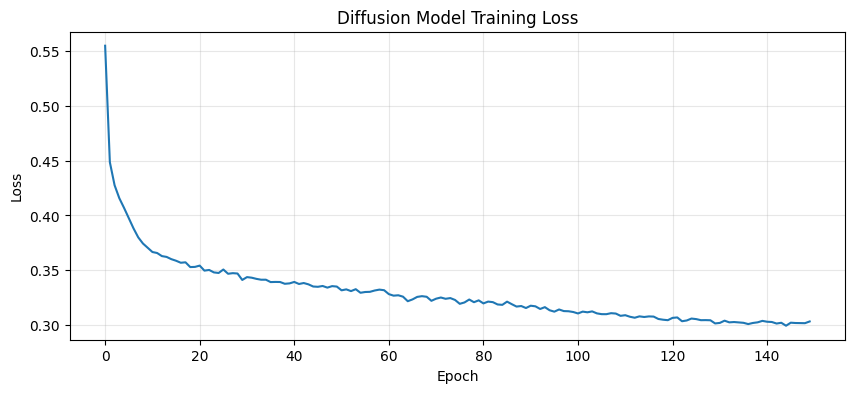

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Diffusion Model Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

---
## Part D: Target Policy with HRM

The target policy is more aligned with HRM than the behavior policy.

In [17]:
class HRMGuidedTargetPolicy(nn.Module):
    """Target policy π(a|s) guided by HRM - better than behavior policy."""

    def __init__(self, env: MazeEnvironment, hrm: HumanReferenceModel,
                 log_std: float = -1.5):
        super().__init__()
        self.env = env
        self.hrm = hrm

        self.network = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)
        )

        self.log_std = nn.Parameter(torch.tensor([log_std, log_std]))
        self._pretrain()

    def _pretrain(self, n_steps: int = 3000):
        """Pre-train target policy to follow HRM guidance closely."""
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)

        for _ in range(n_steps):
            states_np = np.random.rand(64, 2) * (self.env.size - 1) + 0.5
            states = torch.tensor(states_np, dtype=torch.float32)

            target_actions = []
            for s in states_np:
                # Strong alignment with HRM direction
                hrm_dir = self.hrm.get_direction(s)
                goal_dir = self.hrm.get_direction_to_goal(s)

                # Mix: 70% HRM, 30% direct goal
                direction = 0.7 * hrm_dir + 0.3 * goal_dir
                direction = direction / (np.linalg.norm(direction) + 1e-6)

                # Faster speed than behavior (more optimal)
                heatmap_val = self.hrm.get_heatmap_value(s)
                speed = 0.35 + 0.1 * heatmap_val
                action = direction * speed
                target_actions.append(action)

            target = torch.tensor(np.array(target_actions), dtype=torch.float32)
            mean = self.network(states)
            loss = ((mean - target) ** 2).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    def forward(self, state: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        mean = self.network(state)
        std = torch.exp(self.log_std).expand_as(mean)
        return mean, std

    def sample(self, state: torch.Tensor) -> torch.Tensor:
        mean, std = self.forward(state)
        noise = torch.randn_like(mean)
        action = mean + std * noise
        return torch.clamp(action, -0.5, 0.5)

    def log_prob(self, state: torch.Tensor, action: torch.Tensor) -> torch.Tensor:
        mean, std = self.forward(state)
        var = std ** 2
        log_prob = -0.5 * (((action - mean) ** 2) / var + torch.log(2 * np.pi * var))
        return log_prob.sum(dim=-1)

    def score(self, state: torch.Tensor, action: torch.Tensor) -> torch.Tensor:
        """Compute ∇_a log π(a|s)."""
        mean, std = self.forward(state)
        var = std ** 2
        return -(action - mean) / var

In [18]:
# Initialize target policy
print("Training target policy...")
target_policy = HRMGuidedTargetPolicy(env, hrm)
target_policy.to(device)

# Compare policies
test_states = torch.tensor([[2.0, 2.0], [5.0, 5.0], [7.0, 7.0]], dtype=torch.float32)
print("\nPolicy comparison:")
for s in test_states:
    s_np = s.numpy()
    s_gpu = s.unsqueeze(0).to(device)

    with torch.no_grad():
        beta_mean, _ = behavior_policy.policy(s.unsqueeze(0))
        pi_mean, _ = target_policy(s_gpu)

    print(f"  State {s_np}: β={beta_mean.squeeze().numpy()}, π={pi_mean.cpu().squeeze().numpy()}")

Training target policy...

Policy comparison:
  State [2. 2.]: β=[0.10961711 0.1862717 ], π=[0.1701058  0.30528158]
  State [5. 5.]: β=[0.11812247 0.26053616], π=[0.05270344 0.40559733]
  State [7. 7.]: β=[0.09585726 0.15918717], π=[0.13653314 0.28089517]


---
## Part E: Guided Sampling - STITCH-OPE Core

The guidance function:
$$g(\tau) = \alpha \nabla_\tau \sum_t \log \pi(a_t|s_t) - \lambda \nabla_\tau \sum_t \log \beta(a_t|s_t)$$

In [34]:
class GuidedDiffusionSampler:
    """
    Guided Diffusion Sampler implementing STITCH-OPE.
    g(τ) = α∇_τ Σlog π(a|s) - λ∇_τ Σlog β(a|s)
    """

    def __init__(self,
                 diffusion_model: ConditionalDiffusionModel,
                 target_policy: nn.Module,
                 behavior_policy: BehaviorPolicy,
                 dataset: SubTrajectoryDataset,
                 trainer: DiffusionTrainer,
                 hrm: HumanReferenceModel,
                 window_size: int = 8,
                 alpha: float = 1.0,
                 lambda_: float = 0.3):

        self.model = diffusion_model
        self.target_policy = target_policy
        self.behavior_policy = behavior_policy
        self.dataset = dataset
        self.trainer = trainer
        self.hrm = hrm
        self.window_size = window_size
        self.alpha = alpha
        self.lambda_ = lambda_

    def extract_states_actions(self, window: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Extract states and actions from flattened window tensor.
        """
        batch_size = window.shape[0]
        w = self.window_size

        states = []
        actions = []

        for i in range(w):
            # State at index i*4 : i*4+2
            s_i = window[:, i*4 : i*4+2]
            # Action at index i*4+2 : i*4+4
            a_i = window[:, i*4+2 : i*4+4]

            states.append(s_i)
            actions.append(a_i)

        # Final state at index -2 (or w*4 : w*4+2)
        s_final = window[:, w*4 : w*4+2]
        states.append(s_final)

        # Stack
        states = torch.stack(states, dim=1) # (batch, w+1, 2)
        actions = torch.stack(actions, dim=1) # (batch, w, 2)

        return states, actions

    def compute_guidance(self, window: torch.Tensor) -> torch.Tensor:
        """
        Compute STITCH-OPE classifier guidance.
        """
        # CRITICAL FIX: We must re-enable gradients here because sample() is @no_grad
        with torch.enable_grad():
            # Enable gradients for the input window to compute ∇_τ
            window = window.detach().clone()
            window.requires_grad_(True)

            # 1. Unnormalize
            window_unnorm = self.dataset.unnormalize_window(window)

            # 2. Extract
            states, actions = self.extract_states_actions(window_unnorm)

            # 3. Compute scores sum
            total_score = 0
            w = self.window_size

            # Iterate over timesteps
            for t in range(w):
                s_t = states[:, t]
                a_t = actions[:, t]

                # Target policy log_prob
                pi_log_prob = self.target_policy.log_prob(s_t, a_t).sum()

                # Behavior policy log_prob
                beta_log_prob = self.behavior_policy.log_prob(s_t, a_t).sum()

                # Combine
                total_score = total_score + (self.alpha * pi_log_prob - self.lambda_ * beta_log_prob)

            # 4. Compute gradient w.r.t window
            # allow_unused=True handles cases where policies might be flat/zero gradients
            grads = torch.autograd.grad(total_score, window, allow_unused=True)[0]

            if grads is None:
                return torch.zeros_like(window)

            guidance = grads

            # 5. Normalize guidance vector
            norm = torch.norm(guidance, p=2, dim=-1, keepdim=True)
            guidance = guidance / (norm + 1e-6)

            return guidance.detach() # Detach before returning to no_grad context

    @torch.no_grad()
    def sample(self, initial_state: torch.Tensor, n_samples: int = 1,
               guidance_scale: float = 0.5) -> torch.Tensor:
        """
        Guided reverse diffusion sampling (DDPM).
        """
        self.model.eval()
        device = next(self.model.parameters()).device

        # 1. Normalize condition
        initial_state = initial_state.to(device)
        cond = self.dataset.normalize_condition(initial_state).unsqueeze(0).repeat(n_samples, 1)

        # 2. Start from noise
        x = torch.randn(n_samples, self.model.trajectory_dim, device=device)

        # Pre-compute constants for efficiency
        betas = self.trainer.betas.to(device)
        alphas = self.trainer.alphas.to(device)
        alpha_bars = self.trainer.alpha_bars.to(device)

        # 3. Reverse loop
        for t in reversed(range(self.trainer.n_steps)):
            t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)

            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            # Predict noise
            noise_pred = self.model(x, t_batch, cond)

            # Compute mean
            mean = (1 / torch.sqrt(alpha_t)) * (x - (beta_t / torch.sqrt(1 - alpha_bar_t)) * noise_pred)

            # Compute variance
            var = beta_t
            std = torch.sqrt(var)

            # Apply guidance (heuristic: only in middle steps where structure forms)
            if 10 < t < 80:
                guidance = self.compute_guidance(x)
                mean = mean + guidance_scale * var * guidance

            # Sample
            if t > 0:
                noise = torch.randn_like(x)
                x = mean + std * noise
            else:
                x = mean

        # 4. Return unnormalized trajectory
        return self.dataset.unnormalize_window(x)

In [35]:
# Initialize sampler
sampler = GuidedDiffusionSampler(
    diffusion_model=diffusion_model,
    target_policy=target_policy,
    behavior_policy=behavior_policy,
    dataset=dataset,
    trainer=trainer,
    hrm=hrm,
    window_size=WINDOW_SIZE,
    alpha=1.0,
    lambda_=0.3
)

# Test sampling
initial_state = torch.tensor(env.start, dtype=torch.float32, device=device)
samples = sampler.sample(initial_state, n_samples=5, guidance_scale=0.5)
print(f"Sample shape: {samples.shape}")

Sample shape: torch.Size([5, 34])


---
## Part F: Trajectory Stitching

In [36]:
class TrajectoryStitcher:
    """Stitch sub-trajectories using HRM scoring for candidate selection."""

    def __init__(self, sampler: GuidedDiffusionSampler, env: MazeEnvironment,
                 hrm: HumanReferenceModel, window_size: int = 8):
        self.sampler = sampler
        self.env = env
        self.hrm = hrm
        self.window_size = window_size

    def extract_trajectory_from_window(self, window: torch.Tensor) -> Tuple[np.ndarray, np.ndarray]:
        window = window.cpu().numpy()
        states = []
        actions = []

        for i in range(self.window_size):
            idx = i * 4
            states.append(window[idx:idx+2])
            actions.append(window[idx+2:idx+4])
        states.append(window[-2:])

        return np.array(states), np.array(actions)

    def is_valid_trajectory(self, states: np.ndarray) -> bool:
        """Check if all states are valid."""
        for s in states:
            if not self.env.is_valid_position(s):
                return False
        return True

    def stitch_trajectory(self, n_windows: int = 12, n_candidates: int = 8,
                          guidance_scale: float = 0.5) -> Dict:
        """Generate trajectory by stitching windows."""
        all_states = [self.env.start.copy()]
        all_actions = []

        current_state = torch.tensor(self.env.start, dtype=torch.float32, device=device)

        for w_idx in range(n_windows):
            candidates = self.sampler.sample(current_state, n_samples=n_candidates,
                                            guidance_scale=guidance_scale)

            best_score = float('-inf')
            best_window = None

            for i in range(n_candidates):
                window = candidates[i]
                states, actions = self.extract_trajectory_from_window(window)

                if not self.is_valid_trajectory(states):
                    continue

                score = self.hrm.score_trajectory(states)

                if score > best_score:
                    best_score = score
                    best_window = (states, actions)

            if best_window is None:
                states, actions = self.extract_trajectory_from_window(candidates[0])
                states = np.clip(states, 0.5, self.env.size - 0.5)
                best_window = (states, actions)

            states, actions = best_window
            all_states.extend(states[1:].tolist())
            all_actions.extend(actions.tolist())

            current_state = torch.tensor(states[-1], dtype=torch.float32, device=device)

            if np.linalg.norm(states[-1] - self.env.goal) < 0.8:
                break

        return {
            'states': np.array(all_states),
            'actions': np.array(all_actions),
            'reached_goal': np.linalg.norm(all_states[-1] - self.env.goal) < 0.8
        }

In [37]:
# Initialize stitcher and generate trajectories
stitcher = TrajectoryStitcher(sampler, env, hrm, window_size=WINDOW_SIZE)

print("Generating trajectories...")

trajectories_no_guidance = []
trajectories_with_guidance = []

for i in range(15):
    # No guidance
    sampler.alpha = 0.0
    sampler.lambda_ = 0.0
    traj = stitcher.stitch_trajectory(n_windows=12, n_candidates=8, guidance_scale=0.0)
    trajectories_no_guidance.append(traj)

    # With guidance
    sampler.alpha = 1.0
    sampler.lambda_ = 0.3
    traj = stitcher.stitch_trajectory(n_windows=12, n_candidates=8, guidance_scale=0.5)
    trajectories_with_guidance.append(traj)

no_guid_success = np.mean([t['reached_goal'] for t in trajectories_no_guidance])
with_guid_success = np.mean([t['reached_goal'] for t in trajectories_with_guidance])

print(f"\nNo guidance success rate: {no_guid_success*100:.0f}%")
print(f"With guidance success rate: {with_guid_success*100:.0f}%")

Generating trajectories...

No guidance success rate: 40%
With guidance success rate: 73%


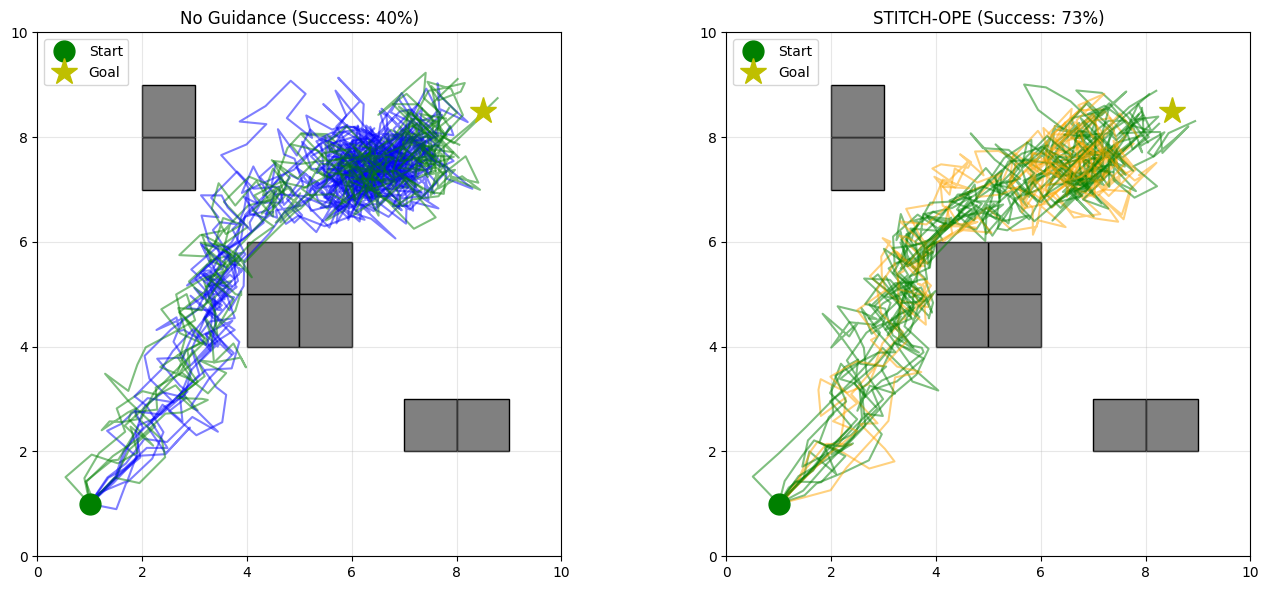

In [38]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
env.render(ax=ax, title=f"No Guidance (Success: {no_guid_success*100:.0f}%)")
for traj in trajectories_no_guidance:
    states = traj['states']
    color = 'green' if traj['reached_goal'] else 'blue'
    ax.plot(states[:, 0], states[:, 1], '-', color=color, alpha=0.5, linewidth=1.5)

ax = axes[1]
env.render(ax=ax, title=f"STITCH-OPE (Success: {with_guid_success*100:.0f}%)")
for traj in trajectories_with_guidance:
    states = traj['states']
    color = 'green' if traj['reached_goal'] else 'orange'
    ax.plot(states[:, 0], states[:, 1], '-', color=color, alpha=0.5, linewidth=1.5)

plt.tight_layout()
plt.show()

---
## Part G: Off-Policy Evaluation & Analysis

In [39]:
def compute_trajectory_return(states: np.ndarray, actions: np.ndarray,
                               env: MazeEnvironment, gamma: float = 0.99) -> float:
    total_return = 0
    discount = 1.0

    for i in range(len(actions)):
        s = states[i]
        dist_to_goal = np.linalg.norm(s - env.goal)
        reward = -0.01 * dist_to_goal

        if i + 1 < len(states):
            if not env.is_valid_position(states[i + 1]):
                reward -= 0.5

        if dist_to_goal < 0.8:
            reward += 10.0

        total_return += discount * reward
        discount *= gamma

    return total_return


def get_ground_truth_returns(env: MazeEnvironment, target_policy: nn.Module,
                              n_trajectories: int = 30, max_steps: int = 80):
    returns = []
    successes = []

    for _ in range(n_trajectories):
        state = env.reset()
        total_return = 0
        discount = 1.0

        for step in range(max_steps):
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                action = target_policy.sample(state_t).squeeze(0).cpu().numpy()

            next_state, reward, done = env.step(action)
            total_return += discount * reward
            discount *= 0.99
            state = next_state

            if done:
                successes.append(1)
                break
        else:
            successes.append(0)

        returns.append(total_return)

    return returns, np.mean(successes)

In [40]:
# Ground truth
print("Computing ground truth...")
gt_returns, gt_success = get_ground_truth_returns(env, target_policy, n_trajectories=30)
print(f"Ground truth: Return = {np.mean(gt_returns):.2f} ± {np.std(gt_returns):.2f}, Success = {gt_success*100:.0f}%")

# Evaluate OPE methods
def evaluate_ope(stitcher, alpha, lambda_, n_traj=15, guidance_scale=0.5):
    stitcher.sampler.alpha = alpha
    stitcher.sampler.lambda_ = lambda_

    returns = []
    successes = []

    for _ in range(n_traj):
        traj = stitcher.stitch_trajectory(n_windows=12, n_candidates=8, guidance_scale=guidance_scale)
        ret = compute_trajectory_return(traj['states'], traj['actions'], env)
        returns.append(ret)
        successes.append(traj['reached_goal'])

    return np.mean(returns), np.std(returns), np.mean(successes)

print("\n" + "="*70)
print(f"{'Method':<35} {'Return':>12} {'Std':>10} {'Success':>10}")
print("-"*70)
print(f"{'Ground Truth (Target Policy)':<35} {np.mean(gt_returns):>12.2f} {np.std(gt_returns):>10.2f} {gt_success*100:>9.0f}%")
print("-"*70)

ret, std, succ = evaluate_ope(stitcher, 0.0, 0.0, guidance_scale=0.0)
print(f"{'No Guidance':<35} {ret:>12.2f} {std:>10.2f} {succ*100:>9.0f}%")

ret, std, succ = evaluate_ope(stitcher, 1.0, 0.0, guidance_scale=0.5)
print(f"{'Target Only (α=1, λ=0)':<35} {ret:>12.2f} {std:>10.2f} {succ*100:>9.0f}%")

ret, std, succ = evaluate_ope(stitcher, 1.0, 0.3, guidance_scale=0.5)
print(f"{'STITCH-OPE (α=1, λ=0.3)':<35} {ret:>12.2f} {std:>10.2f} {succ*100:>9.0f}%")

ret, std, succ = evaluate_ope(stitcher, 1.0, 0.5, guidance_scale=0.5)
print(f"{'Higher λ (α=1, λ=0.5)':<35} {ret:>12.2f} {std:>10.2f} {succ*100:>9.0f}%")

print("="*70)

Computing ground truth...
Ground truth: Return = 4.30 ± 1.40, Success = 100%

Method                                    Return        Std    Success
----------------------------------------------------------------------
Ground Truth (Target Policy)                4.30       1.40       100%
----------------------------------------------------------------------
No Guidance                                 2.09       7.67        53%
Target Only (α=1, λ=0)                     -0.36       3.02        60%
STITCH-OPE (α=1, λ=0.3)                     2.49       8.30        80%
Higher λ (α=1, λ=0.5)                      -1.42       3.00        47%
